# Demo for Computational Design of Shape-Aware Sieves

In [1]:
import os
import sys

FILE_DIR = os.path.abspath(os.getcwd())
DATA_DIR = os.path.abspath(os.path.join(FILE_DIR, os.pardir, 'data'))
PKG_DIR = os.path.abspath(os.path.join(FILE_DIR, os.pardir, 'src'))
sys.path.insert(1, PKG_DIR)

from kaolin.rep import SurfaceMesh
from matplotlib import pyplot as plt
import numpy as np
import polyscope as ps
import torch

from sieves import mesh_utils
from sieves import batched_opt as bopt
from sieves import fabrication as fab
from sieves import testing
from sieves import visualization as vis
from sieves.colors import colors

In [2]:
# Set determinism for all packages with randomness.
testing.set_determinism()

In [3]:
# Initialize Polyscope.
ps.set_up_dir('z_up')
ps.set_front_dir('x_front')
ps.init()

[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.2 (Core Profile) Mesa 22.2.5


## Setup meshes

In [4]:
# Choose a set of meshes for A.
meshes_A_configs = [
    {
        'filename': 'bowtie.stl',
        'fabrication_scale': 25.0,
        'fabrication_offset': None
    }
]

# Choose a set of meshes for B.
meshes_B_configs = [
    {
        'filename': 'sphere.stl',
        'fabrication_scale': 25.0,
        'fabrication_offset': None
    }
]

# Import the meshes.
simulation_scale = 0.01

meshes_A = [mesh_utils.import_mesh_from_config(mesh_A_config, DATA_DIR, simulation_scale)
            for mesh_A_config in meshes_A_configs]

meshes_B = [mesh_utils.import_mesh_from_config(mesh_B_config, DATA_DIR, simulation_scale)
            for mesh_B_config in meshes_B_configs]

# Set an offset for the A meshes to use during optimization.
# Without an offset, actual fabricated results will not work as the A shapes will get stuck in the sieve hole due to friction.
meshes_A_fabrication_offset = 1.0
meshes_A_offset = [mesh_utils.import_mesh_from_config({
                                                 'filename': mesh_A_config['filename'],
                                                 'fabrication_scale': mesh_A_config['fabrication_scale'],
                                                 'fabrication_offset': meshes_A_fabrication_offset
                                               },
                                               DATA_DIR,
                                               simulation_scale)
                   for mesh_A_config in meshes_A_configs]

## Visualize meshes

In [5]:
# Visualize all meshes in Polyscope.

for i, mesh_A in enumerate(meshes_A):
    offset = np.array([i, 0., 0.])
    ps.register_surface_mesh(f'mesh_A_{i}',
                             mesh_A.vertices.clone().detach().cpu().numpy() + offset,
                             mesh_A.faces.clone().detach().cpu().numpy(),
                             edge_width=0.,
                             smooth_shade=False,
                             color=np.array(colors['A'])/255.)
    ps.get_surface_mesh(f'mesh_A_{i}').set_enabled(True)

for i, mesh_B in enumerate(meshes_B):
    offset = np.array([i, 1.5, 0.])
    ps.register_surface_mesh(f'mesh_B_{i}',
                             mesh_B.vertices.clone().detach().cpu().numpy() + offset,
                             mesh_B.faces.clone().detach().cpu().numpy(),
                             edge_width=0.,
                             smooth_shade=False,
                             color=np.array(colors['B'])/255.)
    ps.get_surface_mesh(f'mesh_B_{i}').set_enabled(True)

ps.show()

In [6]:
# Hide all meshes.

for i in range(len(meshes_A)):
    ps.get_surface_mesh(f'mesh_A_{i}').set_enabled(False)

for i in range(len(meshes_B)):
    ps.get_surface_mesh(f'mesh_B_{i}').set_enabled(False)

## Generate sieve hole

### Optimize orientations of $A$ meshes

In [7]:
# Optimize orientations of the A meshes to create a sieve hole that admits them but blocks the B meshes.
fill_holes = True
_, union_mesh, rot_vecs, trans_vecs = bopt.optimize_posn_of_multi_A(meshes_A=meshes_A_offset,
                                                                    meshes_B=meshes_B,
                                                                    mesh_A_fill_soft_mask_holes=fill_holes,
                                                                    pso_verbose=True)

print()
print(f'Rotation vectors for A meshes: {rot_vecs}')
print(f'Translation vectors for A meshes: {trans_vecs}')

Iteration 1/10, best value: 0.1456063836812973, best position: tensor([-0.8940,  0.0360,  0.2368, -0.1406,  1.0084,  0.0677], device='cuda:0')
Iteration 2/10, best value: 0.1456063836812973, best position: tensor([-0.8940,  0.0360,  0.2368, -0.1406,  1.0084,  0.0677], device='cuda:0')
Iteration 3/10, best value: 0.1456063836812973, best position: tensor([-0.8940,  0.0360,  0.2368, -0.1406,  1.0084,  0.0677], device='cuda:0')
Iteration 4/10, best value: 0.1456063836812973, best position: tensor([-0.8940,  0.0360,  0.2368, -0.1406,  1.0084,  0.0677], device='cuda:0')
Iteration 5/10, best value: 0.1456063836812973, best position: tensor([-0.8940,  0.0360,  0.2368, -0.1406,  1.0084,  0.0677], device='cuda:0')
Iteration 6/10, best value: 0.1456063836812973, best position: tensor([-0.8940,  0.0360,  0.2368, -0.1406,  1.0084,  0.0677], device='cuda:0')
Iteration 7/10, best value: 0.1456063836812973, best position: tensor([-0.8940,  0.0360,  0.2368, -0.1406,  1.0084,  0.0677], device='cuda:0')

### Visualize sieve hole and sieve mesh

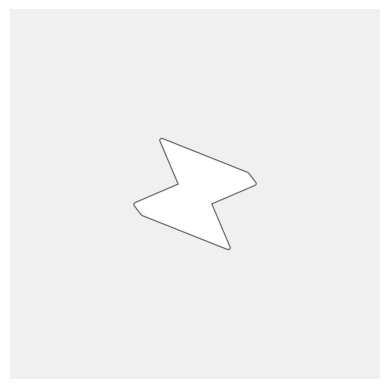

In [8]:
# Visualize sieve hole.
plt.figure()
plt.axis('off')
plt.imshow(vis.get_figure_raster(union_mesh, union_mesh, torch.IntTensor([255, 255, 255]).cuda()))

In [9]:
# Visualize 3D sieve mesh.
sieve_mesh_V, sieve_mesh_F = fab.get_sieve_plate_minus_mesh(mesh=union_mesh,
                                                            scale_factor=(1. / simulation_scale),
                                                            fill_holes=fill_holes,
                                                            sieve_side_length=80.,
                                                            sieve_thickness=60.,
                                                            image_shape=[1024, 1024])
sieve_mesh_V *= simulation_scale

ps.register_surface_mesh('sieve_mesh',
                         sieve_mesh_V,
                         sieve_mesh_F,
                         edge_width=0.,
                         smooth_shade=False,
                         color=np.array(colors['sieve'])/255.)

ps.show()

### Visualize optimized orientation of mesh $A$

In [10]:
mesh_A_idx = 0 # choose index of mesh to visualize from meshes_A

mesh_A = meshes_A[mesh_A_idx]
mesh_A_transformed = mesh_utils.get_transformed_mesh(mesh_A, rot_vecs[mesh_A_idx], trans_vecs[mesh_A_idx])

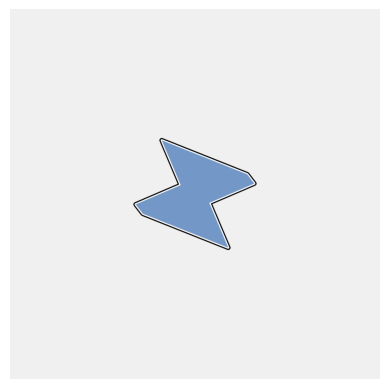

In [11]:
# Visualize raster of A mesh in sieve hole.
plt.figure()
plt.axis('off')
plt.imshow(vis.get_figure_raster(union_mesh, mesh_A_transformed, torch.IntTensor(colors['A']).cuda()))

In [12]:
# Visualize oriented mesh A above sieve hole.
ps.register_surface_mesh('mesh_A_transformed',
                         mesh_A_transformed.vertices.clone().detach().cpu().numpy() + np.array([0., 0., 0.6]),
                         mesh_A_transformed.faces.clone().detach().cpu().numpy(),
                         edge_width=0.,
                         smooth_shade=False,
                         color=np.array(colors['A'])/255.)

ps.get_surface_mesh('mesh_A_transformed').set_enabled(True)

ps.show()

In [13]:
ps.get_surface_mesh('mesh_A_transformed').set_enabled(False) # hide mesh

## Optimize $B$ meshes against sieve hole

### Optimize orientation of $B$ mesh

In [14]:
mesh_B_idx = 0 # choose index of mesh to optimize from meshes_B

mesh_B = meshes_B[mesh_B_idx]

# Optimize mesh B against sieve hole with enhanced parameter values for greater accuracy.
best_loss, best_rot_vec, best_trans_vec = bopt.optimize_posn_of_mesh_B(union_mesh=union_mesh,
                                                                       mesh_B=mesh_B,
                                                                       union_mesh_fill_soft_mask_holes=fill_holes,
                                                                       mesh_B_opt_num_posns=100,
                                                                       mesh_B_opt_iters=500)

mesh_B_transformed = mesh_utils.get_transformed_mesh(mesh_B, best_rot_vec, best_trans_vec)
mesh_B_raster = vis.rasterize_mesh(mesh_B_transformed, pixel_color=torch.tensor(colors['B']).cuda())
union_mesh_raster = vis.rasterize_mesh(union_mesh, pixel_color=torch.tensor(colors['A']).cuda(), fill_holes=fill_holes)
combined_raster = union_mesh_raster + mesh_B_raster

print(f'Best loss for mesh B: {best_loss}')

Best loss for mesh B: 0.19156670570373535


### Visualize optimized orientation of mesh $B$

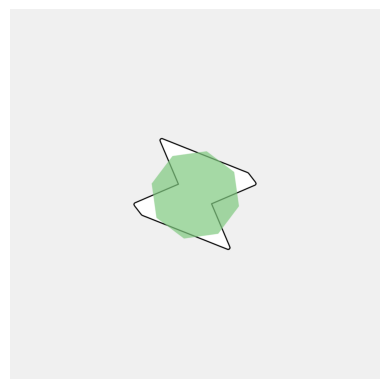

In [15]:
# Visualize raster of B mesh with sieve hole.
plt.figure()
plt.axis('off')
plt.imshow(vis.get_figure_raster(union_mesh, mesh_B_transformed, torch.IntTensor(colors['B']).cuda()))

In [16]:
# Visualize oriented mesh B above sieve hole.
ps.register_surface_mesh('mesh_B_transformed',
                         mesh_B_transformed.vertices.clone().detach().cpu().numpy() + np.array([0., 0., 0.6]),
                         mesh_B_transformed.faces.clone().detach().cpu().numpy(),
                         edge_width=0.,
                         smooth_shade=False,
                         color=np.array(colors['B'])/255.)

ps.get_surface_mesh('mesh_B_transformed').set_enabled(True)

ps.show()

In [17]:
ps.get_surface_mesh('mesh_B_transformed').set_enabled(False) # hide mesh